In [1]:
import pandas as pd
df = pd.read_csv('data/german_credit_data.csv', index_col=0)
display(df.head())
print("--- Información del Dataset ---")
df.info()

#Contar exactamente cuántos valores nulos hay por columna
print("\n--- Valores Nulos por Columna ---")
print(df.isnull().sum())

#Ver las categorías únicas de una columna de texto importante
print("\n--- Propósitos del Crédito ---")
print(df['Purpose'].value_counts())

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 78.1+ KB

--- Valores Nulos por Columna ---
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

--- Propósitos del Crédito ---
Purpose
car    

In [2]:
#Rellenar los valores nulos, indicando que el cliente no tiene esa cuenta
df['Saving accounts'] = df['Saving accounts'].fillna('no_account')
df['Checking account'] = df['Checking account'].fillna('no_account')

#Verificar que los nulos han desaparecido 
print("--- Verificación de Nulos ---")
print(df.isnull().sum())

--- Verificación de Nulos ---
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [3]:
#Identificar automáticamente todas las columnas que son de texto ('object')
columnas_texto = df.select_dtypes(include=['object']).columns
print("Columnas de texto detectadas:", list(columnas_texto))

#Aplicar la transformación
# drop_first=True elimina una columna repetida para no confundir al algoritmo
df_codificado = pd.get_dummies(df, columns=columnas_texto, drop_first=True)

#Ver el dataset actual
print("\n--- Nuevo tamaño de la tabla (Filas, Columnas) ---")
print(df_codificado.shape)

#Mostrar las primeras filas
display(df_codificado.head())

Columnas de texto detectadas: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

--- Nuevo tamaño de la tabla (Filas, Columnas) ---
(1000, 21)


,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_no_account,Saving accounts_quite rich,...,Checking account_moderate,Checking account_no_account,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,True,True,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,True,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
3,45,2,7882,42,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [4]:
import numpy as np

#Creación de una regla de negocio simulada para definir quién es riesgoso
#Si un cliente pide mucho dinero y a muchos meses, tiene más probabilidad de fallar
np.random.seed(42) 

#Calculamos un "puntaje de riesgo" interno
puntaje_riesgo = (df_codificado['Credit amount'] / df_codificado['Credit amount'].max()) * 0.4 + \
                 (df_codificado['Duration'] / df_codificado['Duration'].max()) * 0.4 + \
                 np.random.rand(len(df_codificado)) * 0.2

#Creamos la nueva columna de nuestro modelo: 1 (Mal Pagador) y 0 (Buen Pagador)
#Si su puntaje supera el 0.45, lo marcamos como cliente de alto riesgo
df_codificado['Risk_Default'] = np.where(puntaje_riesgo > 0.45, 1, 0)

print("--- Distribución de nuestra nueva columna de Riesgo ---")
print(df_codificado['Risk_Default'].value_counts())

--- Distribución de nuestra nueva columna de Riesgo ---
Risk_Default
0    883
1    117
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#Separar en "Características" (X) y "Objetivo a predecir" (y)
X = df_codificado.drop('Risk_Default', axis=1) # Todas las columnas MENOS el riesgo
y = df_codificado['Risk_Default']              # SOLAMENTE la columna de riesgo

#División de los datos (80% para estudiar, 20% para el examen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Datos divididos ---")
print(f"El modelo estudiará con: {X_train.shape[0]} clientes.")
print(f"El modelo será evaluado con: {X_test.shape[0]} clientes.\n")

#Entrenamiento del modelo
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train) # La función .fit() es la que hace que la máquina "aprenda"


predicciones = modelo_rf.predict(X_test)

#Resultados
print("--- Resultados del Examen Final ---")
print(classification_report(y_test, predicciones))

--- Datos divididos ---
El modelo estudiará con: 800 clientes.
El modelo será evaluado con: 200 clientes.

--- Resultados del Examen Final ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       180
           1       0.83      0.75      0.79        20

    accuracy                           0.96       200
   macro avg       0.90      0.87      0.88       200
weighted avg       0.96      0.96      0.96       200



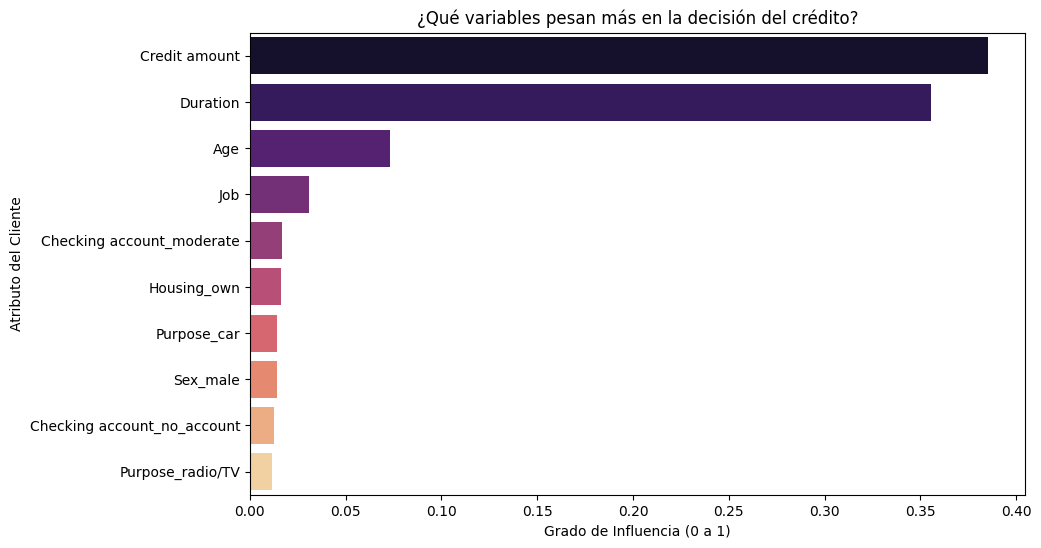

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#Extraer la importancia de las variables desde el modelo entrenado
importancias = modelo_rf.feature_importances_
columnas = X.columns

#Crear un DataFrame ordenado para graficar
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# 3. Graficar el Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, hue='Variable', legend=False, palette='magma')
plt.title('¿Qué variables pesan más en la decisión del crédito?')
plt.xlabel('Grado de Influencia (0 a 1)')
plt.ylabel('Atributo del Cliente')
plt.show()

In [7]:
import pyodbc
from sqlalchemy import create_engine
import urllib

server = 'DESKTOP-I05AF0O' 
database = 'Proyecto_Riesgo'
params = urllib.parse.quote_plus(f"DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes")
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

#Exportar el DataFrame a SQL
df_codificado.to_sql('Resultados_Riesgo', con=engine, if_exists='replace', index=False)

print("¡Éxito! Los datos del modelo ahora están en SQL Server.")

¡Éxito! Los datos del modelo ahora están en SQL Server.
